# Questão 1

Simulação de um sistema CDMA com três usuários, espalhamento por códigos de Hadamard
de comprimento `8` e análise de recuperação na presença de ruído aditivo e de distorção
no código disponível no receptor.


In [1]:
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import pywt
from scipy.io import loadmat, wavfile
from scipy.linalg import hadamard
from scipy import signal

plt.style.use('seaborn-v0_8-whitegrid')

CWD = Path.cwd().resolve()
if (CWD / 'pratica_5' / 'Aula_Prática_5.pdf').exists():
    REPO_ROOT = CWD
    PRACTICE_DIR = CWD / 'pratica_5'
elif (CWD / 'Aula_Prática_5.pdf').exists():
    PRACTICE_DIR = CWD
    REPO_ROOT = CWD.parent
else:
    PRACTICE_DIR = CWD
    REPO_ROOT = CWD.parent

DATA_DIR = REPO_ROOT / 'data'

def display_rows(rows, float_digits=6):
    if not rows:
        print('Sem dados para exibir.')
        return

    headers = list(rows[0].keys())
    formatted_rows = []
    for row in rows:
        formatted = []
        for header in headers:
            value = row[header]
            if isinstance(value, float):
                formatted.append(f'{value:.{float_digits}f}')
            else:
                formatted.append(str(value))
        formatted_rows.append(formatted)

    widths = []
    for idx, header in enumerate(headers):
        content_width = max(len(row[idx]) for row in formatted_rows)
        widths.append(max(len(header), content_width))

    header_line = ' | '.join(header.ljust(widths[idx]) for idx, header in enumerate(headers))
    separator = '-+-'.join('-' * width for width in widths)
    print(header_line)
    print(separator)
    for row in formatted_rows:
        print(' | '.join(value.ljust(widths[idx]) for idx, value in enumerate(row)))


def mse(reference, estimate):
    reference = np.asarray(reference, dtype=np.float64)
    estimate = np.asarray(estimate, dtype=np.float64)
    return float(np.mean((reference - estimate) ** 2))


def plot_spectrum(ax, signal_in, fs, title, xlim=None):
    freqs = np.fft.rfftfreq(len(signal_in), d=1 / fs)
    mag = np.abs(np.fft.rfft(signal_in))
    ax.plot(freqs, mag)
    ax.set_title(title)
    ax.set_xlabel('Frequencia (Hz)')
    ax.set_ylabel('Magnitude')
    if xlim is not None:
        ax.set_xlim(*xlim)
    ax.grid(True, alpha=0.3)


def coeffs_table(wavelet_name):
    w = pywt.Wavelet(wavelet_name)
    return [
        {'Filtro': 'dec_lo', 'Coeficientes': np.array2string(np.array(w.dec_lo), precision=8, separator=', ')},
        {'Filtro': 'dec_hi', 'Coeficientes': np.array2string(np.array(w.dec_hi), precision=8, separator=', ')},
        {'Filtro': 'rec_lo', 'Coeficientes': np.array2string(np.array(w.rec_lo), precision=8, separator=', ')},
        {'Filtro': 'rec_hi', 'Coeficientes': np.array2string(np.array(w.rec_hi), precision=8, separator=', ')},
    ]


def plot_wavelet_decomposition(signal_in, coeffs, title):
    levels = len(coeffs) - 1
    fig, axes = plt.subplots(levels + 2, 1, figsize=(12, 2.3 * (levels + 2)))
    axes[0].plot(signal_in)
    axes[0].set_title(f'{title} - sinal original')
    axes[0].set_xlabel('Amostra normalizada')
    axes[0].set_ylabel('Amplitude')

    axes[1].plot(coeffs[0])
    axes[1].set_title(f'{title} - aproximacao A{levels}')
    axes[1].set_xlabel('Indice do coeficiente')
    axes[1].set_ylabel('Coef.')

    for idx, detail in enumerate(coeffs[1:], start=1):
        level = levels - idx + 1
        axes[idx + 1].plot(detail)
        axes[idx + 1].set_title(f'{title} - detalhe D{level}')
        axes[idx + 1].set_xlabel('Indice do coeficiente')
        axes[idx + 1].set_ylabel('Coef.')

    plt.tight_layout()
    plt.show()


In [2]:
rng = np.random.default_rng(42)
msg_len = 8
code_len = 8
H = hadamard(code_len).astype(float)
codes = H[[1, 2, 3], :]
messages = rng.choice([-1, 1], size=(3, msg_len))
encoded = [np.kron(messages[k], codes[k]) for k in range(3)]

rows = []
for k in range(3):
    rows.append(
        {
            'Usuario': f'U{k + 1}',
            'Mensagem': ''.join('1' if v > 0 else '0' for v in messages[k]),
            'Energia do codigo': float(np.sum(codes[k] ** 2)),
            'Amostras do sinal codificado': len(encoded[k]),
        }
    )

display_rows(rows, float_digits=4)


Usuario | Mensagem | Energia do codigo | Amostras do sinal codificado
--------+----------+-------------------+-----------------------------
U1      | 01100101 | 8.0000            | 64                          
U2      | 00111111 | 8.0000            | 64                          
U3      | 10101001 | 8.0000            | 64                          


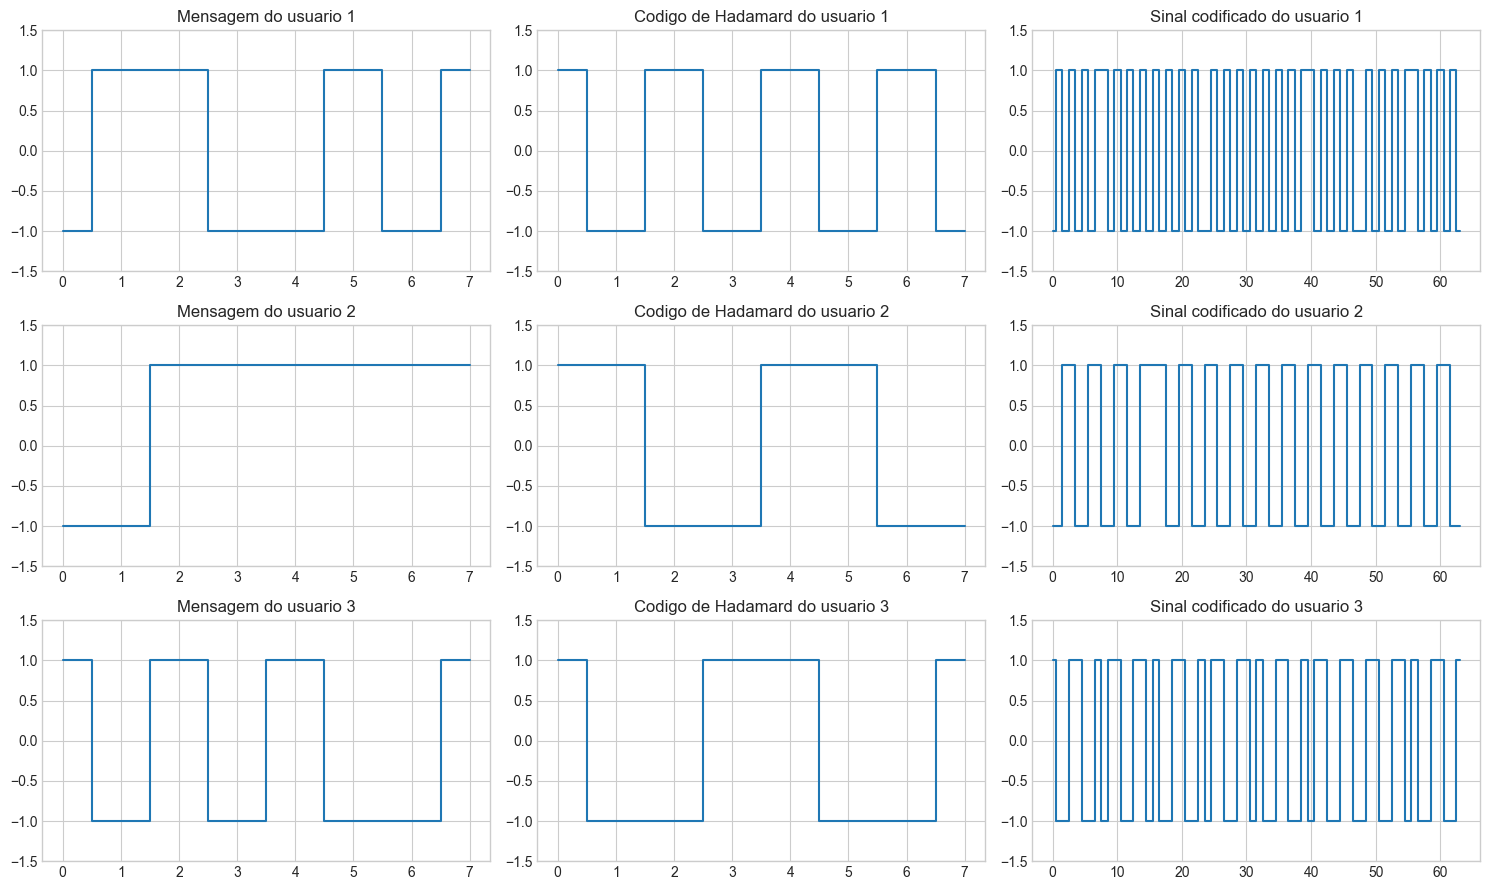

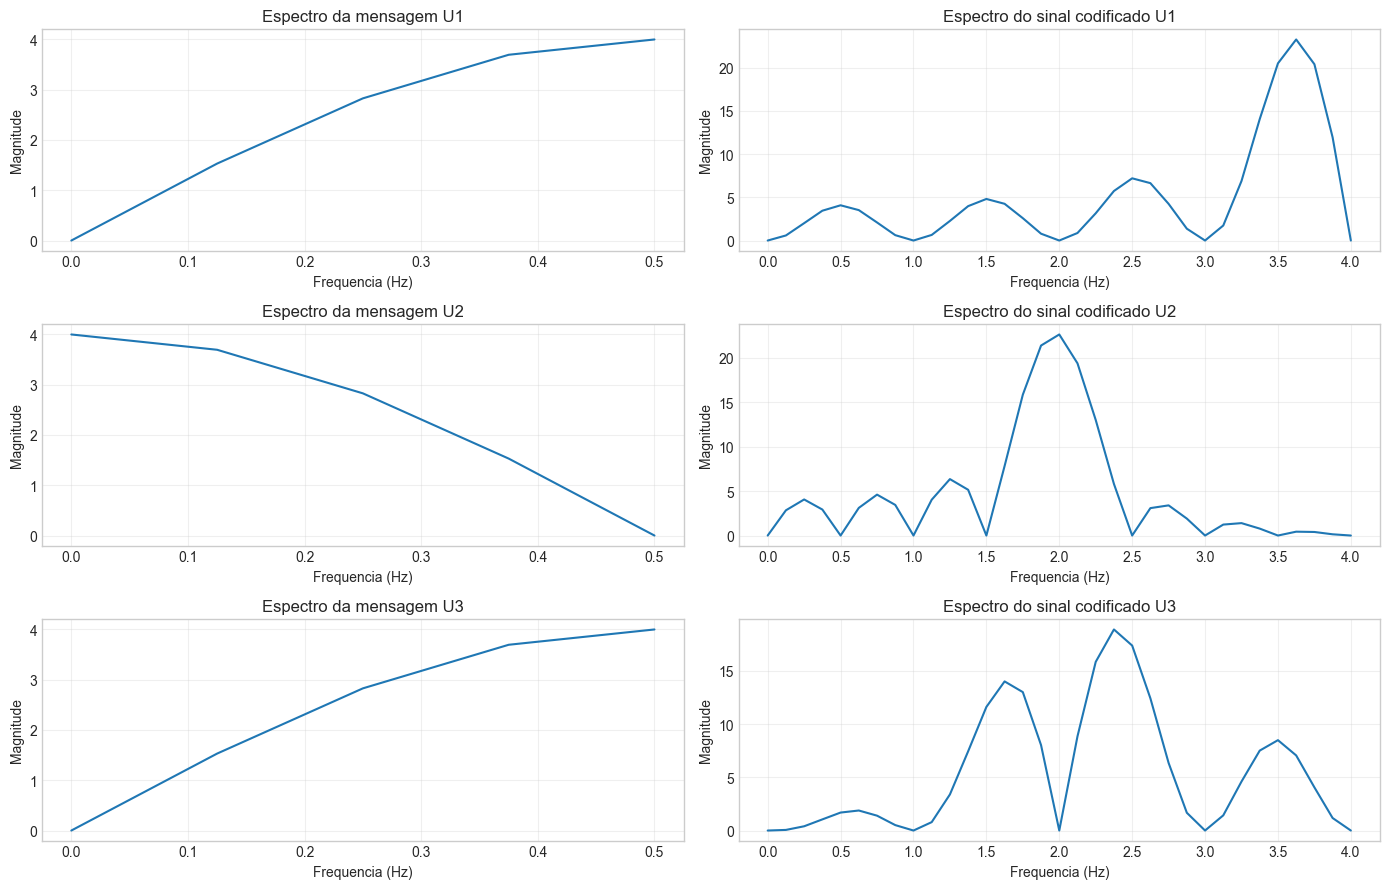

In [3]:
fig, axes = plt.subplots(3, 3, figsize=(15, 9))
fs_chip = code_len

for k in range(3):
    axes[k, 0].step(np.arange(msg_len), messages[k], where='mid')
    axes[k, 0].set_title(f'Mensagem do usuario {k + 1}')
    axes[k, 0].set_ylim(-1.5, 1.5)

    axes[k, 1].step(np.arange(code_len), codes[k], where='mid')
    axes[k, 1].set_title(f'Codigo de Hadamard do usuario {k + 1}')
    axes[k, 1].set_ylim(-1.5, 1.5)

    axes[k, 2].step(np.arange(len(encoded[k])), encoded[k], where='mid')
    axes[k, 2].set_title(f'Sinal codificado do usuario {k + 1}')
    axes[k, 2].set_ylim(-1.5, 1.5)

plt.tight_layout()
plt.show()

fig, axes = plt.subplots(3, 2, figsize=(14, 9))
for k in range(3):
    plot_spectrum(axes[k, 0], messages[k], fs=1.0, title=f'Espectro da mensagem U{k + 1}')
    plot_spectrum(axes[k, 1], encoded[k], fs=fs_chip, title=f'Espectro do sinal codificado U{k + 1}')
plt.tight_layout()
plt.show()


## Recuperação Matemática

Para cada bloco de chips, pode-se escrever:

`y_b = C m_b + w_b`

em que:

- `C ∈ R^(8x3)` contém os códigos dos três usuários como colunas;
- `m_b ∈ {-1, 1}^3` é o vetor de bits transmitidos no bloco `b`;
- `w_b` é o ruído AWGN.

Com códigos ortogonais, `C^T C = 8 I`, então:

`m_b_hat = sign((1/8) C^T y_b)`

Logo, o ruído entra na estimativa como um termo aditivo projetado pelos códigos:

`(1/8) C^T y_b = m_b + (1/8) C^T w_b`

Se o receptor usar um código perturbado `Ĉ`, a recuperação por mínimos quadrados fica:

`m_b_hat = sign((Ĉ^T Ĉ)^(-1) Ĉ^T y_b)`

e o erro passa a depender também da distorção na matriz de códigos.


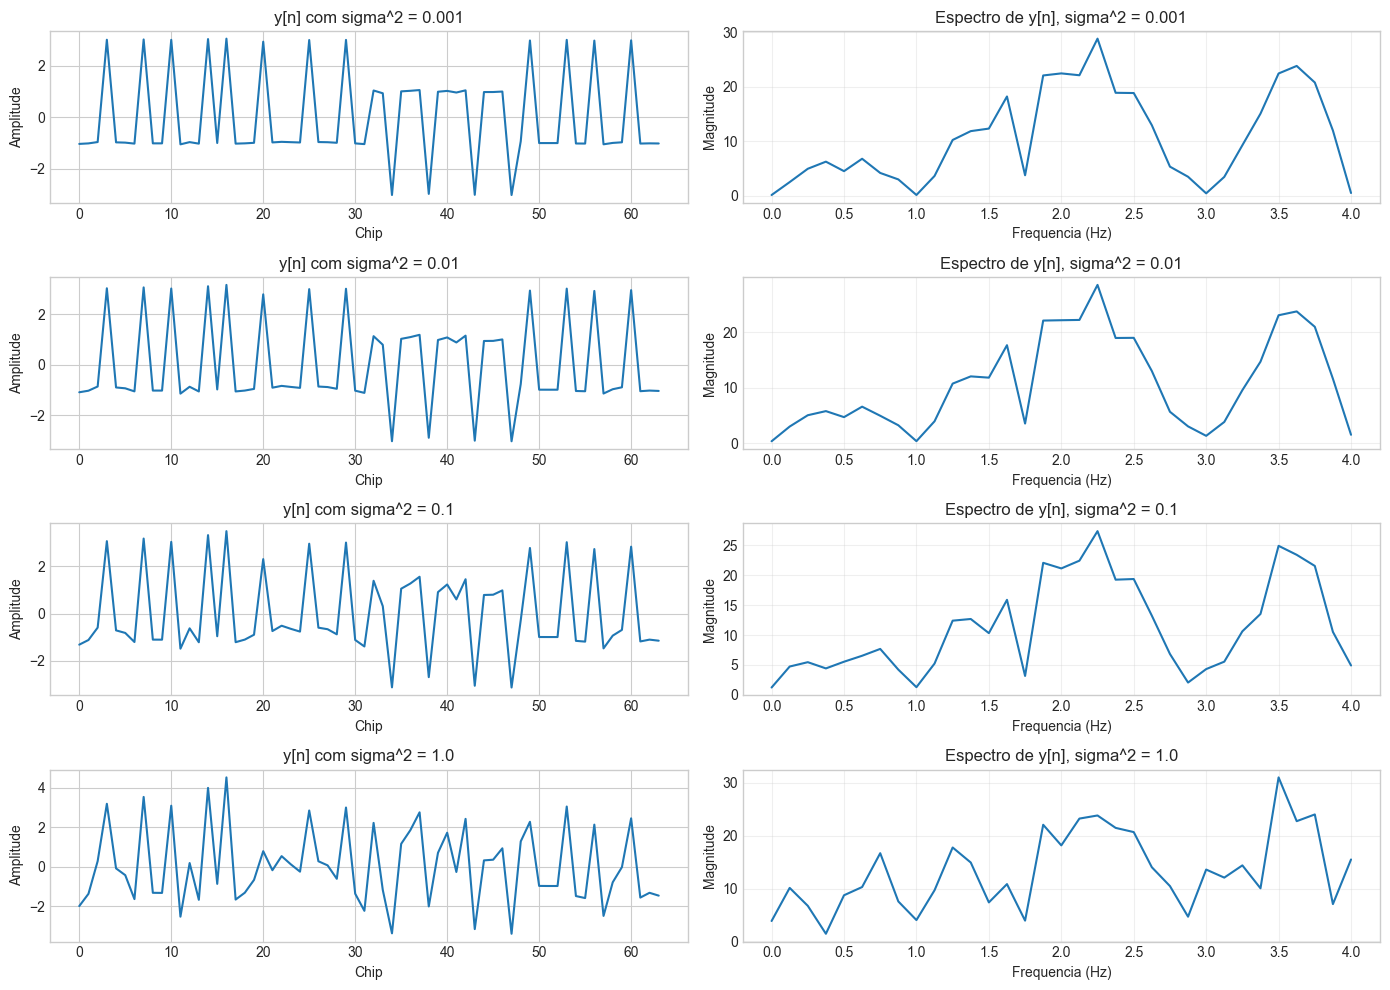

In [4]:
C = codes.T

def build_received(messages, codes, sigma2):
    rng_local = np.random.default_rng(123)
    encoded_local = [np.kron(messages[k], codes[k]) for k in range(messages.shape[0])]
    y_clean = np.sum(encoded_local, axis=0)
    noise = rng_local.normal(0.0, np.sqrt(sigma2), size=y_clean.shape)
    return y_clean + noise

sigma2_values = [1e-3, 1e-2, 1e-1, 1.0]
received_signals = {sigma2: build_received(messages, codes, sigma2) for sigma2 in sigma2_values}

fig, axes = plt.subplots(len(sigma2_values), 2, figsize=(14, 10))
for idx, sigma2 in enumerate(sigma2_values):
    y = received_signals[sigma2]
    axes[idx, 0].plot(y)
    axes[idx, 0].set_title(f'y[n] com sigma^2 = {sigma2}')
    axes[idx, 0].set_xlabel('Chip')
    axes[idx, 0].set_ylabel('Amplitude')
    plot_spectrum(axes[idx, 1], y, fs=fs_chip, title=f'Espectro de y[n], sigma^2 = {sigma2}')

plt.tight_layout()
plt.show()


In [5]:
def decode_blocks(y, C_est):
    blocks = y.reshape(msg_len, code_len)
    decoded = np.zeros((msg_len, 3))
    pinv = np.linalg.pinv(C_est)
    for b in range(msg_len):
        decoded[b] = np.sign(pinv @ blocks[b])
    decoded[decoded == 0] = 1
    return decoded.T

def monte_carlo_awgn(messages, codes, sigma2, n_trials=1500):
    total_errors = 0
    total_bits = messages.size * n_trials
    for trial in range(n_trials):
        encoded_local = [np.kron(messages[k], codes[k]) for k in range(messages.shape[0])]
        y_clean = np.sum(encoded_local, axis=0)
        noise = np.random.default_rng(1000 + trial).normal(0.0, np.sqrt(sigma2), size=y_clean.shape)
        decoded = decode_blocks(y_clean + noise, codes.T)
        total_errors += np.sum(decoded != messages)
    return total_errors / total_bits

def monte_carlo_code_distortion(messages, codes, sigma2, n_trials=1500):
    total_errors = 0
    total_bits = messages.size * n_trials
    y_clean = np.sum([np.kron(messages[k], codes[k]) for k in range(messages.shape[0])], axis=0)
    for trial in range(n_trials):
        distortion = np.random.default_rng(3000 + trial).normal(0.0, np.sqrt(sigma2), size=codes.T.shape)
        C_hat = codes.T + distortion
        decoded = decode_blocks(y_clean, C_hat)
        total_errors += np.sum(decoded != messages)
    return total_errors / total_bits

awgn_rows = []
distort_rows = []

for sigma2 in sigma2_values:
    awgn_rows.append({'sigma^2': sigma2, 'Prob. erro': monte_carlo_awgn(messages, codes, sigma2)})
    distort_rows.append({'sigma^2': sigma2, 'Prob. erro': monte_carlo_code_distortion(messages, codes, sigma2)})

print('Erro com AWGN no canal:')
display_rows(awgn_rows, float_digits=8)
print('\nErro com distorcao no codigo do receptor:')
display_rows(distort_rows, float_digits=8)


Erro com AWGN no canal:
sigma^2    | Prob. erro
-----------+-----------
0.00100000 | 0.00000000
0.01000000 | 0.00000000
0.10000000 | 0.00000000
1.00000000 | 0.00263889

Erro com distorcao no codigo do receptor:
sigma^2    | Prob. erro
-----------+-----------
0.00100000 | 0.00000000
0.01000000 | 0.00000000
0.10000000 | 0.00000000
1.00000000 | 0.04938889


Usuario | Original | AWGN sigma^2=1e-2 | Codigo distorcido sigma^2=1e-2
--------+----------+-------------------+-------------------------------
U1      | 01100101 | 01100101          | 01100101                      
U2      | 00111111 | 00111111          | 00111111                      
U3      | 10101001 | 10101001          | 10101001                      


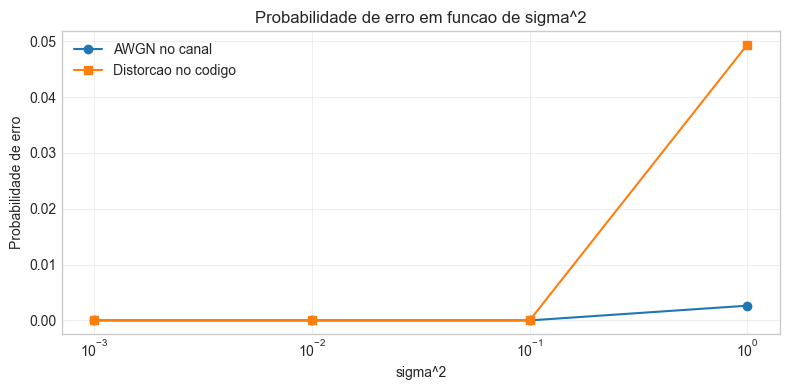

In [6]:
decoded_awgn = decode_blocks(received_signals[1e-2], C)
decoded_distorted = decode_blocks(
    np.sum([np.kron(messages[k], codes[k]) for k in range(messages.shape[0])], axis=0),
    C + np.random.default_rng(7).normal(0.0, np.sqrt(1e-2), size=C.shape),
)

comparison_rows = []
for k in range(3):
    comparison_rows.append(
        {
            'Usuario': f'U{k + 1}',
            'Original': ''.join('1' if v > 0 else '0' for v in messages[k]),
            'AWGN sigma^2=1e-2': ''.join('1' if v > 0 else '0' for v in decoded_awgn[k]),
            'Codigo distorcido sigma^2=1e-2': ''.join('1' if v > 0 else '0' for v in decoded_distorted[k]),
        }
    )

display_rows(comparison_rows)

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot([r['sigma^2'] for r in awgn_rows], [r['Prob. erro'] for r in awgn_rows], marker='o', label='AWGN no canal')
ax.plot([r['sigma^2'] for r in distort_rows], [r['Prob. erro'] for r in distort_rows], marker='s', label='Distorcao no codigo')
ax.set_xscale('log')
ax.set_xlabel('sigma^2')
ax.set_ylabel('Probabilidade de erro')
ax.set_title('Probabilidade de erro em funcao de sigma^2')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


## Comentários

- A codificação por Hadamard espalha o espectro dos sinais dos usuários, o que ajuda na multiplexação por código.
- Com códigos ortogonais, a recuperação por correlação é direta e eficiente.
- O aumento de `sigma^2` no canal eleva a probabilidade de erro.
- Distorções no código do receptor quebram a ortogonalidade e também degradam a recuperação, mesmo sem AWGN no canal.
